# E-Commerce Conversion Funnel Heatmap Matrix

Funnel analysis monitors the conversion drop-off as users move through checkout stages. A funnel matrix plots conversion rates across multiple customer acquisition channels. This notebook simulates user counts across four funnel stages (Home, Product, Cart, Checkout) for six device channels and visualizes the retention rates as a Seaborn Heatmap.



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define funnel stages and device traffic channels (6 channels, 4 stages)
channels = ['Desktop Chrome', 'Desktop Safari', 'Mobile iOS App', 'Mobile Android App', 'Mobile Web Safari', 'Mobile Web Chrome']
stages = ['1_Home', '2_Product_View', '3_Add_To_Cart', '4_Purchase']

# Simulate funnel counts where subsequent stages decrease (decay)
np.random.seed(130)
data_matrix = []

for ch in channels:
    # Starting users at Home stage
    if 'Desktop' in ch:
        start_users = np.random.randint(12000, 18000)
        decays = [1.0, 0.58, 0.18, 0.045] # Desktop conversion decay rates
    elif 'App' in ch:
        start_users = np.random.randint(8000, 11000)
        decays = [1.0, 0.72, 0.32, 0.092] # Native App decay rates (higher conversion)
    else: # Mobile Web
        start_users = np.random.randint(15000, 22000)
        decays = [1.0, 0.48, 0.12, 0.024] # Mobile Web decay rates (lower conversion)
        
    counts = [int(start_users * d) for d in decays]
    data_matrix.append(counts)

df_funnel = pd.DataFrame(data_matrix, index=channels, columns=stages)
df_funnel



,1_Home,2_Product_View,3_Add_To_Cart,4_Purchase
Desktop Chrome,12409,7197,2233,558
Desktop Safari,13267,7694,2388,597
Mobile iOS App,9082,6539,2906,835
Mobile Android App,9936,7153,3179,914
Mobile Web Safari,20805,9986,2496,499
Mobile Web Chrome,20579,9877,2469,493


## Conversion Matrix Calculation

We convert raw user counts into percentage retention metrics relative to the initial 'Home' stage.



In [2]:
df_retention = df_funnel.div(df_funnel['1_Home'], axis=0) * 100
print("Funnel Retention Percentage Rates Matrix:")
df_retention



Funnel Retention Percentage Rates Matrix:


,1_Home,2_Product_View,3_Add_To_Cart,4_Purchase
Desktop Chrome,100.0,57.998227,17.995004,4.496736
Desktop Safari,100.0,57.993518,17.999548,4.499887
Mobile iOS App,100.0,71.999560,31.997357,9.194010
Mobile Android App,100.0,71.990741,31.994767,9.198873
Mobile Web Safari,100.0,47.998077,11.997116,2.398462
Mobile Web Chrome,100.0,47.995529,11.997668,2.395646


## Annotated Funnel Heatmap

Using Seaborn, we plot the retention matrix as a heatmap, adding percentage labels and a diverging coolwarm colorbar.



<cell>:15: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



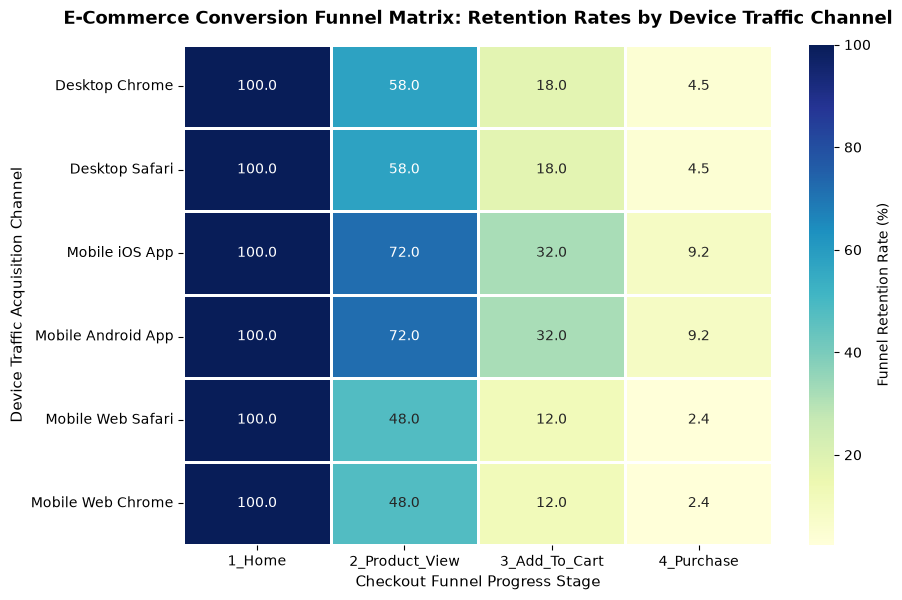

In [3]:
plt.figure(figsize=(9.5, 6.5))

sns.heatmap(
    df_retention, 
    annot=True, 
    fmt=".1f", 
    cmap='YlGnBu', 
    linewidths=0.8,
    cbar_kws={'label': 'Funnel Retention Rate (%)'}
)

plt.title('E-Commerce Conversion Funnel Matrix: Retention Rates by Device Traffic Channel', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Checkout Funnel Progress Stage', fontsize=11)
plt.ylabel('Device Traffic Acquisition Channel', fontsize=11)
plt.show()
